<a href="https://colab.research.google.com/github/Muhfaden/ailsi-tasi/blob/main/AILSI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AILSI — AI Liquidity Stress Index for the Saudi Equity Market (TASI)

### The idea

Global financial-conditions indices (Chicago Fed NFCI, OFR FSI, the bank FCIs) ignore the Saudi
market, while local quant work usually stops at price forecasting. Yet because the riyal is **pegged
to the US dollar** (SAR 3.75 since 1986), SAMA effectively imports US monetary policy — so Fed
tightening, a stronger dollar, and widening global credit spreads transmit into Saudi funding
conditions almost mechanically. Add oil-fiscal dynamics and post-2019 foreign-flow sensitivity, and
TASI becomes a market whose stress is heavily **imported** yet unmonitored by any purpose-built,
transparent, liquidity-aware gauge. **AILSI fills that gap.**

> This is **not** a price predictor. AILSI converts many signals into one 0–100 stress score,
> forecasts it, explains its drivers, and quantifies the downside risk to a hypothetical \$1M position.

In [15]:
%cd /content/drive/MyDrive/AILSI_Project

/content/drive/MyDrive/AILSI_Project


In [16]:
# === Portable setup =========================================================
# Idempotent: installs missing packages, then imports what Step 1 needs.
# ============================================================================
import importlib.util, subprocess, sys
from pathlib import Path

def _ensure(*pkgs):
    """pip-install any package that isn't importable yet (pip name -> import name handled)."""
    name = {"scikit-learn": "sklearn", "pyarrow": "pyarrow"}
    missing = [p for p in pkgs if importlib.util.find_spec(name.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

_ensure("pandas", "numpy", "matplotlib", "pyarrow", "yfinance")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# yfinance occasionally can't reach the network; import defensively so we can still fall back.
try:
    import yfinance as yf
except Exception:
    yf = None
    print("yfinance not importable — will use cache/synthetic for market data.")

np.random.seed(42)
RANDOM_STATE = 42
%matplotlib inline

# --- Find the repo root (folder holding README.md / requirements.txt), else cwd ---
def _find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "README.md").exists() or (base / "requirements.txt").exists():
            return base
    return Path.cwd()

ROOT           = _find_root()
DATA_RAW       = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
ARTEFACT_DIR   = ROOT / "artefacts"
for d in (DATA_RAW, DATA_PROCESSED, ARTEFACT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Analysis window: 2010 -> today. Long enough for monthly ML, spans multiple stress regimes.
START = "2010-01-01"
END   = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)

print(f"pandas    {pd.__version__}")
print(f"yfinance  {yf.__version__ if yf else 'not installed'}")
print(f"root      {ROOT}")
print(f"raw cache {DATA_RAW}")
print(f"window    {START} -> {END}")

pandas    2.2.2
yfinance  0.2.66
root      /content/drive/MyDrive/AILSI_Project
raw cache /content/drive/MyDrive/AILSI_Project/data/raw
window    2010-01-01 -> 2026-06-22


In [17]:
# FRED series: (id, label, block, freq, stress_sign, release_lag_months)
FRED_CATALOGUE = [
    # Oil & external (Saudi is oil- and USD-exposed)
    ("DCOILBRENTEU", "Brent crude oil (USD/bbl)",    "Oil & external",      "D", -1, 0),
    ("DCOILWTICO",   "WTI crude oil (USD/bbl)",      "Oil & external",      "D", -1, 0),
    ("DTWEXBGS",     "USD broad index",              "Oil & external",      "D", +1, 0),
    # Market stress
    ("VIXCLS",       "CBOE VIX (US implied vol)",    "Market stress",       "D", +1, 0),
    # Funding & credit (stress often shows here first)
    ("BAMLH0A0HYM2", "US high-yield OAS",            "Funding & credit",    "D", +1, 0),
    ("BAMLC0A0CM",   "US investment-grade OAS",      "Funding & credit",    "D", +1, 0),
    # Rates & curve / policy (the peg channel)
    ("DGS10",        "10Y Treasury yield",           "Rates & curve",       "D", +1, 0),
    ("DGS2",         "2Y Treasury yield",            "Rates & curve",       "D", +1, 0),
    ("T10Y2Y",       "10Y-2Y term spread",           "Rates & curve",       "D", -1, 0),
    ("DFF",          "Effective Fed Funds (daily)",  "Rates & policy (peg)","D", +1, 0),
    ("FEDFUNDS",     "Fed Funds rate (monthly)",     "Rates & policy (peg)","M", +1, 1),
    # Money & liquidity
    ("M2SL",         "US M2 money stock",            "Money & liquidity",   "M", -1, 1),
    # Inflation
    ("CPIAUCSL",     "US CPI (all items, SA)",       "Inflation",           "M", +1, 1),
    ("SAUCPIALLMINMEI","Saudi CPI (OECD, best-effort)","Inflation",         "M", +1, 1),
]

# Market series from Yahoo Finance: (ticker, label)
TICKER_CATALOGUE = [
    ("^TASI",   "Tadawul All Share Index"),   # the market we monitor
    ("2222.SR", "Saudi Aramco"),              # oil-linked liquidity texture
    ("1180.SR", "Al Rajhi Bank"),             # non-oil contrast
]

catalogue = pd.DataFrame(
    [{"series_id": i, "label": l, "block": b, "freq": f,
      "stress_sign": s, "release_lag_m": r, "source": "FRED"}
     for (i, l, b, f, s, r) in FRED_CATALOGUE]
    + [{"series_id": t, "label": l, "block": "Saudi market", "freq": "D",
        "stress_sign": np.nan, "release_lag_m": 0, "source": "yfinance"}
       for (t, l) in TICKER_CATALOGUE]
)
print(f"{len(catalogue)} series across {catalogue['block'].nunique()} blocks\n")
catalogue

17 series across 8 blocks



,series_id,label,block,freq,stress_sign,release_lag_m,source
0,DCOILBRENTEU,Brent crude oil (USD/bbl),Oil & external,D,-1.0,0,FRED
1,DCOILWTICO,WTI crude oil (USD/bbl),Oil & external,D,-1.0,0,FRED
2,DTWEXBGS,USD broad index,Oil & external,D,1.0,0,FRED
3,VIXCLS,CBOE VIX (US implied vol),Market stress,D,1.0,0,FRED
4,BAMLH0A0HYM2,US high-yield OAS,Funding & credit,D,1.0,0,FRED
5,BAMLC0A0CM,US investment-grade OAS,Funding & credit,D,1.0,0,FRED
6,DGS10,10Y Treasury yield,Rates & curve,D,1.0,0,FRED
7,DGS2,2Y Treasury yield,Rates & curve,D,1.0,0,FRED
8,T10Y2Y,10Y-2Y term spread,Rates & curve,D,-1.0,0,FRED
9,DFF,Effective Fed Funds (daily),Rates & policy (peg),D,1.0,0,FRED


In [18]:
DATA_SOURCE = {}   # series_id -> "live" | "cache" | "synthetic"

# ---- synthetic fallback (offline/CI only; never used when the network is up) ----
def _synth_index(freq):
    if freq == "M":
        return pd.date_range(START, END, freq="MS")
    return pd.bdate_range(START, END)

def _synth_fred(series_id, freq):
    """Plausible-shaped stand-in. Shape only — NOT real data."""
    rng = np.random.default_rng(abs(hash(series_id)) % (2**32))
    idx = _synth_index(freq); n = len(idx)
    sid = series_id.upper()
    if "OIL" in sid or "BRENT" in sid or "WTI" in sid:           # oil: GBM-ish
        x = 70 * np.exp(np.cumsum(rng.normal(0, 0.02, n))); x = np.clip(x, 15, 140)
    elif sid == "VIXCLS":                                        # vol: mean-reverting + spikes
        x = 18 + np.cumsum(rng.normal(0, 0.8, n)); x = np.clip(np.abs(x), 9, 80)
    elif "OAS" in sid or sid.startswith("BAML"):                 # credit spread
        base = 4.0 if "H0A0" in sid else 1.4
        x = np.clip(base + np.cumsum(rng.normal(0, 0.03, n)), 0.4, 15)
    elif sid in ("DGS10", "DGS2", "DFF", "FEDFUNDS"):            # rates
        x = np.clip(2.5 + np.cumsum(rng.normal(0, 0.02, n)), 0.0, 8)
    elif sid == "T10Y2Y":                                        # term spread (can be negative)
        x = np.clip(1.0 + np.cumsum(rng.normal(0, 0.02, n)), -1.5, 3.0)
    elif sid == "DTWEXBGS":                                      # USD index
        x = 115 + np.cumsum(rng.normal(0, 0.1, n)); x = np.clip(x, 90, 135)
    elif sid == "M2SL":                                          # money stock: trend
        x = 9000 * np.exp(np.linspace(0, 0.9, n)) + rng.normal(0, 50, n)
    else:                                                        # CPI-like index: gentle uptrend
        x = 240 * np.exp(np.linspace(0, 0.35, n)) + rng.normal(0, 0.5, n)
    return pd.DataFrame({"date": idx, series_id.lower(): x})

def _synth_prices(ticker):
    rng = np.random.default_rng(abs(hash(ticker)) % (2**32))
    idx = pd.bdate_range(START, END); n = len(idx)
    close = 100 * np.exp(np.cumsum(rng.normal(0.0002, 0.013, n)))
    intraday = np.abs(rng.normal(0, 0.008, n))
    high = close * (1 + intraday); low = close * (1 - intraday)
    open_ = low + rng.random(n) * (high - low)
    vol = rng.integers(1_000_000, 8_000_000, n)
    df = pd.DataFrame({"open": open_, "high": high, "low": low, "close": close,
                       "adj_close": close, "volume": vol}, index=idx)
    df.index.name = "date"
    return df

# ---- live-first fetchers with cache + synthetic fallback ----
def fetch_fred(series_id, freq="D"):
    cache = DATA_RAW / f"fred_{series_id}.parquet"
    url = ("https://fred.stlouisfed.org/graph/fredgraph.csv"
           f"?id={series_id}&cosd={START}&coed={END}")
    try:
        raw = pd.read_csv(url, parse_dates=["observation_date"])
        raw.columns = ["date", series_id.lower()]
        raw = raw[pd.to_numeric(raw[series_id.lower()], errors="coerce").notna()]
        raw[series_id.lower()] = raw[series_id.lower()].astype(float)
        raw.to_parquet(cache, index=False)
        DATA_SOURCE[series_id] = "live"
        return raw
    except Exception as exc:
        if cache.exists():
            DATA_SOURCE[series_id] = "cache"
            return pd.read_parquet(cache)
        DATA_SOURCE[series_id] = "synthetic"
        print(f"  ! {series_id}: live+cache failed ({type(exc).__name__}) -> SYNTHETIC")
        return _synth_fred(series_id, freq)

def fetch_prices(ticker):
    cache = DATA_RAW / f"px_{ticker.replace('^','').replace('.','_')}.parquet"
    if yf is not None:
        try:
            raw = yf.download(ticker, start=START, end=END, auto_adjust=False, progress=False)
            if raw.empty:
                raise RuntimeError("empty response")
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.columns = [c.lower().replace(" ", "_") for c in raw.columns]
            raw.index.name = "date"
            raw.to_parquet(cache)
            DATA_SOURCE[ticker] = "live"
            return raw
        except Exception as exc:
            print(f"  ! {ticker}: yfinance failed ({type(exc).__name__})")
    if cache.exists():
        DATA_SOURCE[ticker] = "cache"
        return pd.read_parquet(cache)
    DATA_SOURCE[ticker] = "synthetic"
    print(f"  ! {ticker}: live+cache failed -> SYNTHETIC")
    return _synth_prices(ticker)

print("Fetch helpers ready.")

Fetch helpers ready.


## 1.3 · Pull the macro series (FRED)

In [19]:
fred_raw = {}
for sid, label, block, freq, sign, lag in FRED_CATALOGUE:
    df = fetch_fred(sid, freq=freq)
    fred_raw[sid] = df
    src = DATA_SOURCE[sid]
    print(f"  {sid:16s} {src:9s} rows={len(df):5d}  ({label})")

print(f"\nPulled {len(fred_raw)} FRED series.")

  DCOILBRENTEU     live      rows= 4161  (Brent crude oil (USD/bbl))
  DCOILWTICO       live      rows= 4126  (WTI crude oil (USD/bbl))
  DTWEXBGS         live      rows= 4095  (USD broad index)
  VIXCLS           live      rows= 4171  (CBOE VIX (US implied vol))
  BAMLH0A0HYM2     live      rows=  785  (US high-yield OAS)
  BAMLC0A0CM       live      rows=  784  (US investment-grade OAS)
  DGS10            live      rows= 4117  (10Y Treasury yield)
  DGS2             live      rows= 4117  (2Y Treasury yield)
  T10Y2Y           live      rows= 4118  (10Y-2Y term spread)
  DFF              live      rows= 6012  (Effective Fed Funds (daily))
  FEDFUNDS         live      rows=  197  (Fed Funds rate (monthly))
  M2SL             live      rows=  196  (US M2 money stock)
  CPIAUCSL         live      rows=  196  (US CPI (all items, SA))
  ! SAUCPIALLMINMEI: live+cache failed (HTTPError) -> SYNTHETIC
  SAUCPIALLMINMEI  synthetic rows=  198  (Saudi CPI (OECD, best-effort))

Pulled 14 FRED seri

## 1.4 · Pull the market series (Yahoo Finance)

`^TASI` is the market we monitor; Aramco (`2222.SR`) and Al Rajhi (`1180.SR`) give an oil-linked vs.
non-oil contrast we'll use for liquidity texture later.

In [20]:
mkt_raw = {}
for ticker, label in TICKER_CATALOGUE:
    df = fetch_prices(ticker)
    mkt_raw[ticker] = df
    src = DATA_SOURCE[ticker]
    rng_str = f"{df.index.min().date()} -> {df.index.max().date()}"
    print(f"  {ticker:9s} {src:9s} rows={len(df):5d}  {rng_str}  ({label})")

print(f"\nPulled {len(mkt_raw)} market series.")

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ^TASI"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^TASI']: YFTzMissingError('possibly delisted; no timezone found')


  ! ^TASI: yfinance failed (RuntimeError)
  ! ^TASI: live+cache failed -> SYNTHETIC
  ^TASI     synthetic rows= 4297  2010-01-01 -> 2026-06-22  (Tadawul All Share Index)
  2222.SR   live      rows= 1630  2019-12-11 -> 2026-06-21  (Saudi Aramco)
  1180.SR   live      rows= 2929  2014-11-12 -> 2026-06-21  (Al Rajhi Bank)

Pulled 3 market series.


In [21]:
def _summarise(name, s):
    s = s.dropna()
    if len(s) < 2:
        return dict(series=name, n=len(s), start=None, end=None, gap_days=None, missing=int(s.isna().sum()))
    gap = pd.Series(s.index).diff().median()
    return dict(series=name, n=len(s),
                start=s.index.min().date(), end=s.index.max().date(),
                gap_days=int(gap.days) if pd.notna(gap) else None)

rows = []
for sid, df in fred_raw.items():
    ser = df.set_index("date")[sid.lower()]
    r = _summarise(sid, ser); r["source"] = DATA_SOURCE[sid]
    r["block"] = catalogue.set_index("series_id").loc[sid, "block"]
    rows.append(r)
for ticker, df in mkt_raw.items():
    ser = df["adj_close"] if "adj_close" in df.columns else df["close"]
    r = _summarise(ticker, ser); r["source"] = DATA_SOURCE[ticker]
    r["block"] = "Saudi market"
    rows.append(r)

coverage = pd.DataFrame(rows)[["series","block","source","n","start","end","gap_days"]]
coverage

,series,block,source,n,start,end,gap_days
0,DCOILBRENTEU,Oil & external,live,4161,2010-01-04,2026-06-15,1
1,DCOILWTICO,Oil & external,live,4126,2010-01-04,2026-06-15,1
2,DTWEXBGS,Oil & external,live,4095,2010-01-04,2026-06-12,1
3,VIXCLS,Market stress,live,4171,2010-01-04,2026-06-19,1
4,BAMLH0A0HYM2,Funding & credit,live,785,2023-06-23,2026-06-19,1
5,BAMLC0A0CM,Funding & credit,live,784,2023-06-23,2026-06-19,1
6,DGS10,Rates & curve,live,4117,2010-01-04,2026-06-17,1
7,DGS2,Rates & curve,live,4117,2010-01-04,2026-06-17,1
8,T10Y2Y,Rates & curve,live,4118,2010-01-04,2026-06-18,1
9,DFF,Rates & policy (peg),live,6012,2010-01-01,2026-06-17,1


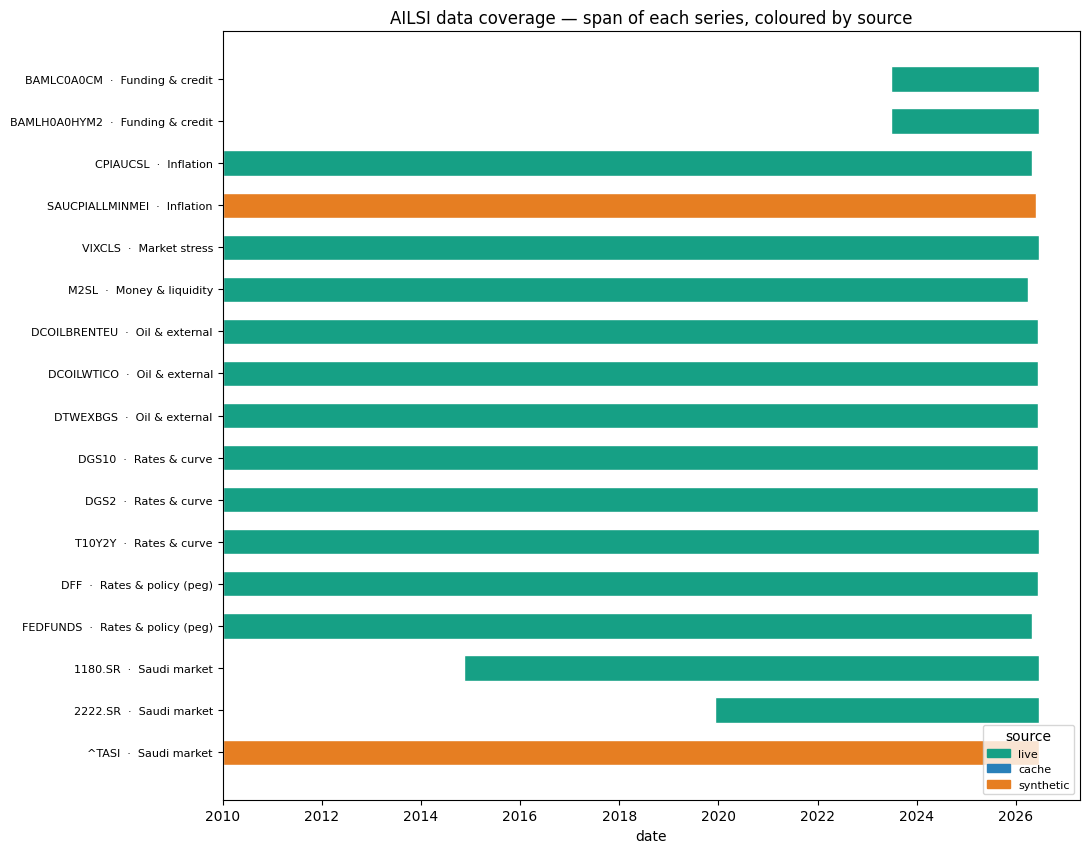

saved /content/drive/MyDrive/AILSI_Project/artefacts/01_coverage_map.png


In [22]:
src_colour = {"live": "#16a085", "cache": "#2980b9", "synthetic": "#e67e22"}
cov = coverage.dropna(subset=["start", "end"]).copy()
cov["start"] = pd.to_datetime(cov["start"]); cov["end"] = pd.to_datetime(cov["end"])
cov = cov.sort_values(["block", "series"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 0.42 * len(cov) + 1.5))
for y, row in cov.iterrows():
    ax.barh(y, (row["end"] - row["start"]).days, left=row["start"],
            color=src_colour.get(row["source"], "#888"), edgecolor="white", height=0.6)
ax.set_yticks(range(len(cov)))
ax.set_yticklabels([f"{r.series}  ·  {r.block}" for r in cov.itertuples()], fontsize=8)
ax.invert_yaxis()
ax.set_title("AILSI data coverage — span of each series, coloured by source")
ax.set_xlabel("date")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in src_colour.values()]
ax.legend(handles, src_colour.keys(), title="source", loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(ARTEFACT_DIR / "01_coverage_map.png", dpi=120, bbox_inches="tight")
plt.show()
print("saved", ARTEFACT_DIR / "01_coverage_map.png")

In [23]:
n_syn = sum(v == "synthetic" for v in DATA_SOURCE.values())
n_live = sum(v == "live" for v in DATA_SOURCE.values())
n_cache = sum(v == "cache" for v in DATA_SOURCE.values())
bar = "=" * 72
print(bar)
print(f"  DATA SOURCE SUMMARY   live={n_live}   cache={n_cache}   synthetic={n_syn}")
if n_syn:
    print("  " + "!" * 68)
    print("  WARNING: this run contains SYNTHETIC (fake) series — for offline development")
    print("  only. Re-run on Colab/with network for real FRED + Yahoo data before any")
    print("  analysis or submission.")
    print("  synthetic: " + ", ".join(s for s, v in DATA_SOURCE.items() if v == "synthetic"))
else:
    print("  All series are REAL (live/cache). Good to proceed.")
print(bar)

# record provenance next to the data for auditability
pd.Series(DATA_SOURCE, name="source").to_csv(DATA_RAW / "_data_source.csv")

  DATA SOURCE SUMMARY   live=15   cache=0   synthetic=2
  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  only. Re-run on Colab/with network for real FRED + Yahoo data before any
  analysis or submission.
  synthetic: SAUCPIALLMINMEI, ^TASI


In [24]:
# --- Final sanity checks ---
assert len(fred_raw) == len(FRED_CATALOGUE),  "missing a FRED series"
assert len(mkt_raw)  == len(TICKER_CATALOGUE), "missing a market series"

# ^TASI must be present and non-trivial
tasi = mkt_raw["^TASI"]
assert len(tasi) > 250, f"^TASI too short: {len(tasi)} rows"

# every series produced a usable, finite value column
for sid, df in fred_raw.items():
    col = sid.lower()
    assert col in df.columns, f"{sid}: value column missing"
    assert np.isfinite(df[col].dropna()).all(), f"{sid}: non-finite values"

# raw parquet cache written for at least the live/cache series
n_parquet = len(list(DATA_RAW.glob("*.parquet")))
print(f"raw parquet files on disk: {n_parquet}")

# provenance recorded
assert (DATA_RAW / "_data_source.csv").exists(), "data-source provenance not written"

print(f"\n\u2713 Step 1 complete — {len(fred_raw)} macro + {len(mkt_raw)} market series, "
      f"window {START} -> {END}.")

raw parquet files on disk: 15

✓ Step 1 complete — 14 macro + 3 market series, window 2010-01-01 -> 2026-06-22.
